# TRABAJO ACADÉMICO INTELIGENCIA ARTIFICIAL 2025-2

El dataset de denuncias policiales ha sido obtenido de la Plataforma Nacional de Datos Abiertos, abarca todas las denuncias en diferentes departamentos en los periodos desde enero 2018 a agosto 2025.

## Librerías

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# from sklearn.preprocessing import LabelEncoder, minmax_scale, scale

## Carga de datos

Descripción de los datos:

1) Anio: Año de ocurrencia de hechos delictivos

2) Mes: 1-12, mes de ocurrencia de hechos delictivos

3) Dpto_Hecho_New: Departamento de ocurrencia de hechos delictivos

4) Prov_Hecho: Provincia de ocurrencia de hechos delictivos

5) Dist_Hecho: Distrito de ocurrencia de hechos delictivos

6) Ubigeo_Hecho: Ubigeo del distrito de ocurrencia de hechos delictivos




In [ ]:
INPUT_FILE_NAME="Denuncias_Policiales.csv"

In [ ]:
df_denuncias = pd.read_csv(INPUT_FILE_NAME)

In [ ]:
df_denuncias.head()

,ANIO,MES,DPTO_HECHO_NEW,PROV_HECHO,DIST_HECHO,UBIGEO_HECHO,P_MODALIDADES,cantidad
0,2018,1,AMAZONAS,BAGUA,ARAMANGO,10202,Otros,6
1,2018,1,AMAZONAS,BAGUA,ARAMANGO,10202,Violencia contra la mujer e integrantes,1
2,2018,1,AMAZONAS,BAGUA,BAGUA,10201,Estafa,2
3,2018,1,AMAZONAS,BAGUA,BAGUA,10201,Hurto,25
4,2018,1,AMAZONAS,BAGUA,BAGUA,10201,Otros,64


In [ ]:
df_denuncias.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 328953 entries, 0 to 328952
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   ANIO            328953 non-null  int64 
 1   MES             328953 non-null  int64 
 2   DPTO_HECHO_NEW  328953 non-null  object
 3   PROV_HECHO      328953 non-null  object
 4   DIST_HECHO      328953 non-null  object
 5   UBIGEO_HECHO    328953 non-null  int64 
 6   P_MODALIDADES   328953 non-null  object
 7   cantidad        328953 non-null  int64 
dtypes: int64(4), object(4)
memory usage: 20.1+ MB


Verificando que no existan valores nulos en el dataset

In [ ]:
{att : df_denuncias[df_denuncias[att].isnull()].shape[0] for att in df_denuncias.columns}

{'ANIO': 0,
 'MES': 0,
 'DPTO_HECHO_NEW': 0,
 'PROV_HECHO': 0,
 'DIST_HECHO': 0,
 'UBIGEO_HECHO': 0,
 'P_MODALIDADES': 0,
 'cantidad': 0}

In [ ]:
null_pct = (df_denuncias.isna().sum() / len(df_denuncias)).sort_values(ascending=False) * 100
print("\\nPorcentaje de nulos por columna (%):")
print(null_pct)

\nPorcentaje de nulos por columna (%):
ANIO              0.0
MES               0.0
DPTO_HECHO_NEW    0.0
PROV_HECHO        0.0
DIST_HECHO        0.0
UBIGEO_HECHO      0.0
P_MODALIDADES     0.0
cantidad          0.0
dtype: float64


In [ ]:
df_denuncias.nunique()

,0
ANIO,8
MES,12
DPTO_HECHO_NEW,26
PROV_HECHO,195
DIST_HECHO,1687
UBIGEO_HECHO,1838
P_MODALIDADES,7
cantidad,899


In [ ]:
df_denuncias['DPTO_HECHO_NEW'].unique()

array(['AMAZONAS', 'ANCASH', 'APURIMAC', 'AREQUIPA', 'AYACUCHO',
       'CAJAMARCA', 'CUSCO', 'HUANCAVELICA', 'HUANUCO', 'ICA', 'JUNIN',
       'LA LIBERTAD', 'LAMBAYEQUE', 'LIMA METROPOLITANA', 'LORETO',
       'MADRE DE DIOS', 'MOQUEGUA', 'PASCO', 'PIURA',
       'PROV. CONST. DEL CALLAO', 'PUNO', 'REGION LIMA', 'SAN MARTIN',
       'TACNA', 'TUMBES', 'UCAYALI'], dtype=object)

In [ ]:
df_denuncias['P_MODALIDADES'].unique()

array(['Otros', 'Violencia contra la mujer e integrantes', 'Estafa',
       'Hurto', 'Robo', 'Extorsión', 'Homicidio'], dtype=object)

In [ ]:
df_denuncias[df_denuncias['DIST_HECHO'] == 'COMAS']

,ANIO,MES,DPTO_HECHO_NEW,PROV_HECHO,DIST_HECHO,UBIGEO_HECHO,P_MODALIDADES,cantidad
1604,2018,1,LIMA METROPOLITANA,LIMA,COMAS,150110,Estafa,5
1605,2018,1,LIMA METROPOLITANA,LIMA,COMAS,150110,Extorsión,6
1606,2018,1,LIMA METROPOLITANA,LIMA,COMAS,150110,Homicidio,1
1607,2018,1,LIMA METROPOLITANA,LIMA,COMAS,150110,Hurto,246
1608,2018,1,LIMA METROPOLITANA,LIMA,COMAS,150110,Otros,511
...,...,...,...,...,...,...,...,...
327634,2025,8,LIMA METROPOLITANA,LIMA,COMAS,150110,Homicidio,5
327635,2025,8,LIMA METROPOLITANA,LIMA,COMAS,150110,Hurto,221
327636,2025,8,LIMA METROPOLITANA,LIMA,COMAS,150110,Otros,416
327637,2025,8,LIMA METROPOLITANA,LIMA,COMAS,150110,Robo,130


In [ ]:
df_denuncias.loc[df_denuncias['DIST_HECHO']=='COMAS', ['ANIO', 'MES', 'P_MODALIDADES', 'cantidad']]

,ANIO,MES,P_MODALIDADES,cantidad
1604,2018,1,Estafa,5
1605,2018,1,Extorsión,6
1606,2018,1,Homicidio,1
1607,2018,1,Hurto,246
1608,2018,1,Otros,511
...,...,...,...,...
327634,2025,8,Homicidio,5
327635,2025,8,Hurto,221
327636,2025,8,Otros,416
327637,2025,8,Robo,130


Creando encoders para variables categóricas (Label Encoding)

In [ ]:
categoricals = ['DPTO_HECHO_NEW', 'PROV_HECHO', 'DIST_HECHO', 'P_MODALIDADES']
numericals = ['ANIO', 'MES', 'UBIGEO_HECHO', 'cantidad']

In [ ]:
from sklearn.preprocessing import LabelEncoder

# manejo de variables categóricas
def treat_categoricals(source_df, columns):
  target_df = source_df.copy()

  for c in columns:
    unique_values = target_df[c].nunique() # cant. categorias_unicas por columna
    label_encoder = LabelEncoder()
    target_df[c] = label_encoder.fit_transform(target_df[c])
  return target_df

In [ ]:
df_denuncias = treat_categoricals(df_denuncias,categoricals)

In [ ]:
df_denuncias

,ANIO,MES,DPTO_HECHO_NEW,PROV_HECHO,DIST_HECHO,UBIGEO_HECHO,P_MODALIDADES,cantidad
0,2018,1,0,18,85,10202,4,6
1,2018,1,0,18,85,10202,6,1
2,2018,1,0,18,119,10201,0,2
3,2018,1,0,18,119,10201,3,25
4,2018,1,0,18,119,10201,4,64
...,...,...,...,...,...,...,...,...
328948,2025,8,25,134,1018,250301,3,4
328949,2025,8,25,134,1018,250301,4,7
328950,2025,8,25,134,1018,250301,6,9
328951,2025,8,25,150,1154,250401,3,1


In [ ]:
df_denuncias[['DIST_HECHO','UBIGEO_HECHO']].corr()

,DIST_HECHO,UBIGEO_HECHO
DIST_HECHO,1.000000,0.090152
UBIGEO_HECHO,0.090152,1.000000


In [ ]:
df_denuncias[['DPTO_HECHO_NEW','UBIGEO_HECHO']].corr()

,DPTO_HECHO_NEW,UBIGEO_HECHO
DPTO_HECHO_NEW,1.000000,0.945297
UBIGEO_HECHO,0.945297,1.000000


In [ ]:
df_denuncias.corr()

,ANIO,MES,DPTO_HECHO_NEW,PROV_HECHO,DIST_HECHO,UBIGEO_HECHO,P_MODALIDADES,cantidad
ANIO,1.000000,-0.106220,0.003361,0.004590,0.001427,0.006226,-0.047622,-0.009252
MES,-0.106220,1.000000,-0.002305,-0.000514,-0.001578,-0.001898,0.002890,-0.005880
DPTO_HECHO_NEW,0.003361,-0.002305,1.000000,0.259819,0.074520,0.945297,-0.053483,0.054207
PROV_HECHO,0.004590,-0.000514,0.259819,1.000000,0.108378,0.341214,-0.020185,0.019218
DIST_HECHO,0.001427,-0.001578,0.074520,0.108378,1.000000,0.090152,0.004238,-0.013831
UBIGEO_HECHO,0.006226,-0.001898,0.945297,0.341214,0.090152,1.000000,-0.049622,0.060458
P_MODALIDADES,-0.047622,0.002890,-0.053483,-0.020185,0.004238,-0.049622,1.000000,0.073712
cantidad,-0.009252,-0.005880,0.054207,0.019218,-0.013831,0.060458,0.073712,1.000000


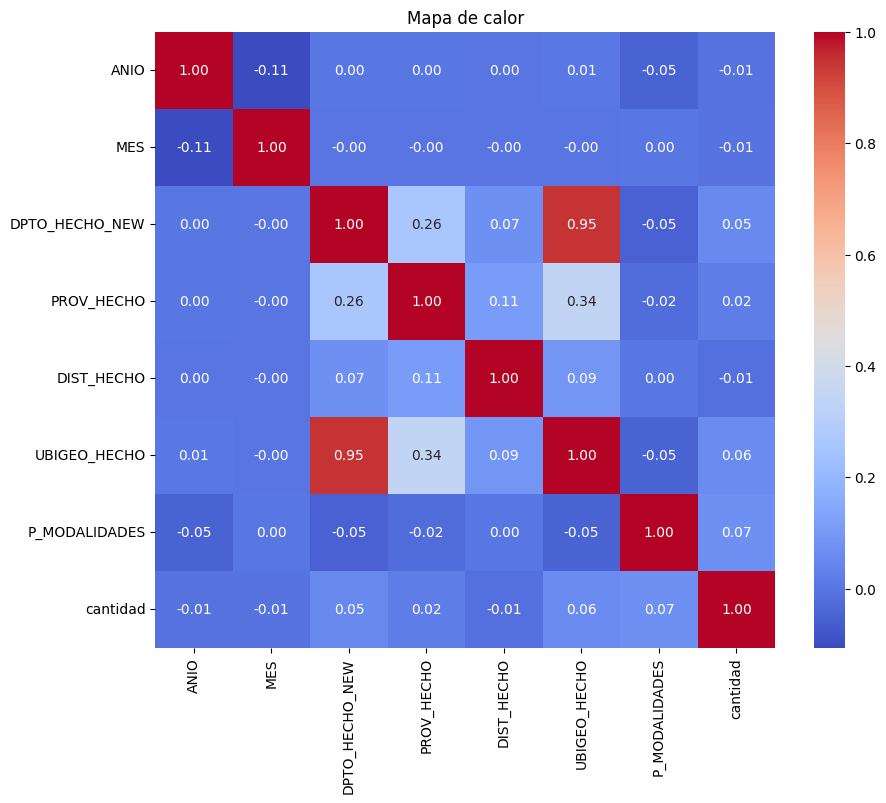

In [ ]:
correlation_matrix = df_denuncias.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de calor')
plt.show()